In [1]:
!pip install statsbombpy scikit-learn xgboost lightgbm shap pandas numpy matplotlib seaborn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import warnings
import os

from statsbombpy import sb

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

print("All imports successful.")

All imports successful.


In [3]:
COMPETITIONS = [
    {"competition_id": 43, "season_id": 106, "name": "FIFA World Cup 2022"},
    {"competition_id": 55, "season_id": 282, "name": "UEFA Euro 2024"},
    {"competition_id": 9,  "season_id": 281, "name": "Bundesliga 2023/2024"},
    {"competition_id": 1267, "season_id": 107, "name": "African Cup of Nations 2023"},
    {"competition_id": 53, "season_id": 315, "name": "UEFA Women's Euro 2025"},
    {"competition_id": 7,  "season_id": 235, "name": "Ligue 1 2022/2023"},
]
WINDOW_MIN   = 15
MIN_POST_MIN = 5
IMPACT_POS_THRESHOLD =  0.10
IMPACT_NEG_THRESHOLD = -0.10

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Config set. Window={WINDOW_MIN}min | Thresholds: +{IMPACT_POS_THRESHOLD} / {IMPACT_NEG_THRESHOLD}")

Config set. Window=15min | Thresholds: +0.1 / -0.1


In [4]:
def get_score_at_minute(events_df, team_name, minute):
    goals = events_df[
        (events_df["type"] == "Shot") &
        (events_df["shot_outcome"] == "Goal") &
        (events_df["minute"] < minute)
    ]
    team_goals = goals[goals["team"] == team_name].shape[0]
    opp_goals  = goals[goals["team"] != team_name].shape[0]
    return team_goals, opp_goals

def get_xg_in_window(events_df, team_name, start_min, end_min):
    window = events_df[
        (events_df["type"] == "Shot") &
        (events_df["minute"] >= start_min) &
        (events_df["minute"] < end_min)
    ].copy()
    team_xg = window[window["team"] == team_name]["shot_statsbomb_xg"].sum()
    opp_xg  = window[window["team"] != team_name]["shot_statsbomb_xg"].sum()
    return round(team_xg, 4), round(opp_xg, 4)

def get_event_counts_in_window(events_df, team_name, start_min, end_min):
    window = events_df[
        (events_df["team"] == team_name) &
        (events_df["minute"] >= start_min) &
        (events_df["minute"] < end_min)
    ]
    shots     = (window["type"] == "Shot").sum()
    passes    = (window["type"] == "Pass").sum()
    pressures = (window["type"] == "Pressure").sum()
    return int(shots), int(passes), int(pressures)

def get_position_group(position_name):
    if not position_name:
        return "Unknown"
    pos = position_name.lower()
    if any(p in pos for p in ["forward", "wing", "striker", "second striker"]):
        return "FW"
    elif any(p in pos for p in ["midfield", "attacking mid", "defensive mid"]):
        return "MF"
    elif any(p in pos for p in ["back", "sweeper", "wing back"]):
        return "DF"
    elif "goalkeeper" in pos or "keeper" in pos:
        return "GK"
    else:
        return "Unknown"

In [5]:
def classify_impact(score):
    if score > IMPACT_POS_THRESHOLD:
        return "Positive"
    elif score < IMPACT_NEG_THRESHOLD:
        return "Negative"
    else:
        return "Neutral"

In [6]:
def get_game_phase(minute):
    if minute <= 30:
        return "0-30"
    elif minute <= 60:
        return "31-60"
    elif minute <= 75:
        return "61-75"
    else:
        return "76-90+"

In [7]:
print("\nLoading match lists from StatsBomb...")
all_matches = []

for comp in COMPETITIONS:
    try:
        matches = sb.matches(
            competition_id=comp["competition_id"],
            season_id=comp["season_id"]
        )
        matches["competition_name"] = comp["name"]
        all_matches.append(matches)
        print(f"OK: {comp['name']}: {len(matches)} matches")
    except Exception as e:
        print(f"FAILED: {comp['name']}: {e}")

matches_df = pd.concat(all_matches, ignore_index=True)
print(f"\nTotal matches loaded: {len(matches_df)}")


Loading match lists from StatsBomb...
OK: FIFA World Cup 2022: 64 matches
OK: UEFA Euro 2024: 51 matches
OK: Bundesliga 2023/2024: 34 matches
OK: African Cup of Nations 2023: 52 matches
OK: UEFA Women's Euro 2025: 31 matches
OK: Ligue 1 2022/2023: 32 matches

Total matches loaded: 264


In [8]:
print("\nExtracting substitution-level features...")
records = []
failed  = 0
match_ids = matches_df["match_id"].tolist()

i = 0
for match_id in match_ids:

    if i % 20 == 0:
        print(f"   Progress: {i}/{len(match_ids)} matches | Samples so far: {len(records)}")
    i += 1

    try:
        events = sb.events(match_id=match_id)

        # Normalize columns
        if "type" in events.columns and events["type"].dtype == object:
            if type(events["type"].iloc[0]) == dict:
                events["type"] = events["type"].apply(lambda x: x.get("name", "") if type(x) == dict else x)

        if "shot_outcome" in events.columns and events["shot_outcome"].dtype == object:
            if type(events["shot_outcome"].dropna().iloc[0]) == dict:
                events["shot_outcome"] = events["shot_outcome"].apply(
                    lambda x: x.get("name", "") if type(x) == dict else x
                )

        if "team" in events.columns and events["team"].dtype == object:
            if type(events["team"].iloc[0]) == dict:
                events["team"] = events["team"].apply(lambda x: x.get("name", "") if type(x) == dict else x)

        if "shot_statsbomb_xg" not in events.columns:
            events["shot_statsbomb_xg"] = 0.0
        events["shot_statsbomb_xg"] = pd.to_numeric(events["shot_statsbomb_xg"], errors="coerce").fillna(0.0)

        subs = events[events["type"] == "Substitution"].copy()
        if subs.empty:
            continue

        match_row  = matches_df[matches_df["match_id"] == match_id].iloc[0]
        home_team  = match_row.get("home_team", {})
        if type(home_team) == dict:
            home_team = home_team.get("home_team_name", "")

        match_minute_max = events["minute"].max()
        sub_seq_tracker = {}

        for _, sub in subs.iterrows():
            sub_min  = int(sub["minute"])
            team     = sub["team"] if type(sub["team"]) == str else sub["team"].get("name", "")

            if not team:
                continue

            time_remaining = 90 - sub_min
            if time_remaining < MIN_POST_MIN:
                continue

            # Extract position of the player going OFF
            raw_position = sub.get("position", None)
            if type(raw_position) == dict:
                position_name = raw_position.get("name", "")
            elif type(raw_position) == str:
                position_name = raw_position
            else:
                position_name = ""
            position_group = get_position_group(position_name)

            sub_seq_tracker[team] = sub_seq_tracker.get(team, 0) + 1
            sub_sequence = sub_seq_tracker[team]

            pre_start = max(0, sub_min - WINDOW_MIN)
            pre_end   = sub_min

            team_xg_prev, opp_xg_prev = get_xg_in_window(events, team, pre_start, pre_end)
            shots_prev, passes_prev, pressures_prev = get_event_counts_in_window(
                events, team, pre_start, pre_end
            )
            team_goals, opp_goals = get_score_at_minute(events, team, sub_min)
            score_diff   = team_goals - opp_goals
            is_home      = 1 if team == home_team else 0
            xg_diff_prev = round(team_xg_prev - opp_xg_prev, 4)

            post_start = sub_min
            post_end   = min(sub_min + WINDOW_MIN, int(match_minute_max) + 1)

            team_xg_next, opp_xg_next = get_xg_in_window(events, team, post_start, post_end)
            xg_diff_next = round(team_xg_next - opp_xg_next, 4)

            impact_score = round(xg_diff_next - xg_diff_prev, 4)
            impact_label = classify_impact(impact_score)

            records.append({
                "match_id":         match_id,
                "competition":      match_row.get("competition_name", ""),
                "team":             team,
                "sub_minute":       sub_min,
                "score_diff":       score_diff,
                "is_home":          is_home,
                "time_remaining":   time_remaining,
                "sub_sequence":     sub_sequence,
                "game_phase":       get_game_phase(sub_min),
                "position_name":    position_name,
                "position_group":   position_group,
                "team_xg_prev15":   team_xg_prev,
                "opp_xg_prev15":    opp_xg_prev,
                "xg_diff_prev15":   xg_diff_prev,
                "shots_prev15":     shots_prev,
                "passes_prev15":    passes_prev,
                "pressures_prev15": pressures_prev,
                "team_xg_next15":   team_xg_next,
                "opp_xg_next15":    opp_xg_next,
                "xg_diff_next15":   xg_diff_next,
                "impact_score":     impact_score,
                "impact_label":     impact_label,
            })

    except Exception as e:
        failed += 1
        continue

print(f"\nExtraction complete!")
print(f"   Total substitution samples: {len(records)}")
print(f"   Failed matches (skipped):   {failed}")


Extracting substitution-level features...
   Progress: 0/264 matches | Samples so far: 0
   Progress: 20/264 matches | Samples so far: 168
   Progress: 40/264 matches | Samples so far: 310
   Progress: 60/264 matches | Samples so far: 469
   Progress: 80/264 matches | Samples so far: 612
   Progress: 100/264 matches | Samples so far: 772
   Progress: 120/264 matches | Samples so far: 934
   Progress: 140/264 matches | Samples so far: 1077
   Progress: 160/264 matches | Samples so far: 1215
   Progress: 180/264 matches | Samples so far: 1362
   Progress: 200/264 matches | Samples so far: 1517
   Progress: 220/264 matches | Samples so far: 1670
   Progress: 240/264 matches | Samples so far: 1828
   Progress: 260/264 matches | Samples so far: 1972

Extraction complete!
   Total substitution samples: 2008
   Failed matches (skipped):   0


In [9]:
df = pd.DataFrame(records)

print("Dataset Overview:")
print(f"   Shape: {df.shape}")

print("\nImpact Label Distribution:")
print(df["impact_label"].value_counts())

print("\nLabel Percentages:")
print(df["impact_label"].value_counts(normalize=True).round(3) * 100)

print("\nPosition Group Distribution:")
print(df["position_group"].value_counts())

# Encode game phase as number
phase_map = {"0-30": 0, "31-60": 1, "61-75": 2, "76-90+": 3}
df["game_phase_enc"] = df["game_phase"].map(phase_map)

# Encode position group as number
position_map = {"FW": 0, "MF": 1, "DF": 2, "GK": 3, "Unknown": 4}
df["position_group_enc"] = df["position_group"].map(position_map)

# Save to CSV
import os
os.makedirs("outputs", exist_ok=True)
df.to_csv("outputs/substitutions_phase1_raw.csv", index=False)

print("\nDataset saved to outputs/substitutions_phase1_raw.csv")

Dataset Overview:
   Shape: (2008, 22)

Impact Label Distribution:
impact_label
Positive    861
Negative    732
Neutral     415
Name: count, dtype: int64

Label Percentages:
impact_label
Positive   42.9000
Negative   36.5000
Neutral    20.7000
Name: proportion, dtype: float64

Position Group Distribution:
position_group
FW    857
MF    846
DF    300
GK      5
Name: count, dtype: int64

Dataset saved to outputs/substitutions_phase1_raw.csv


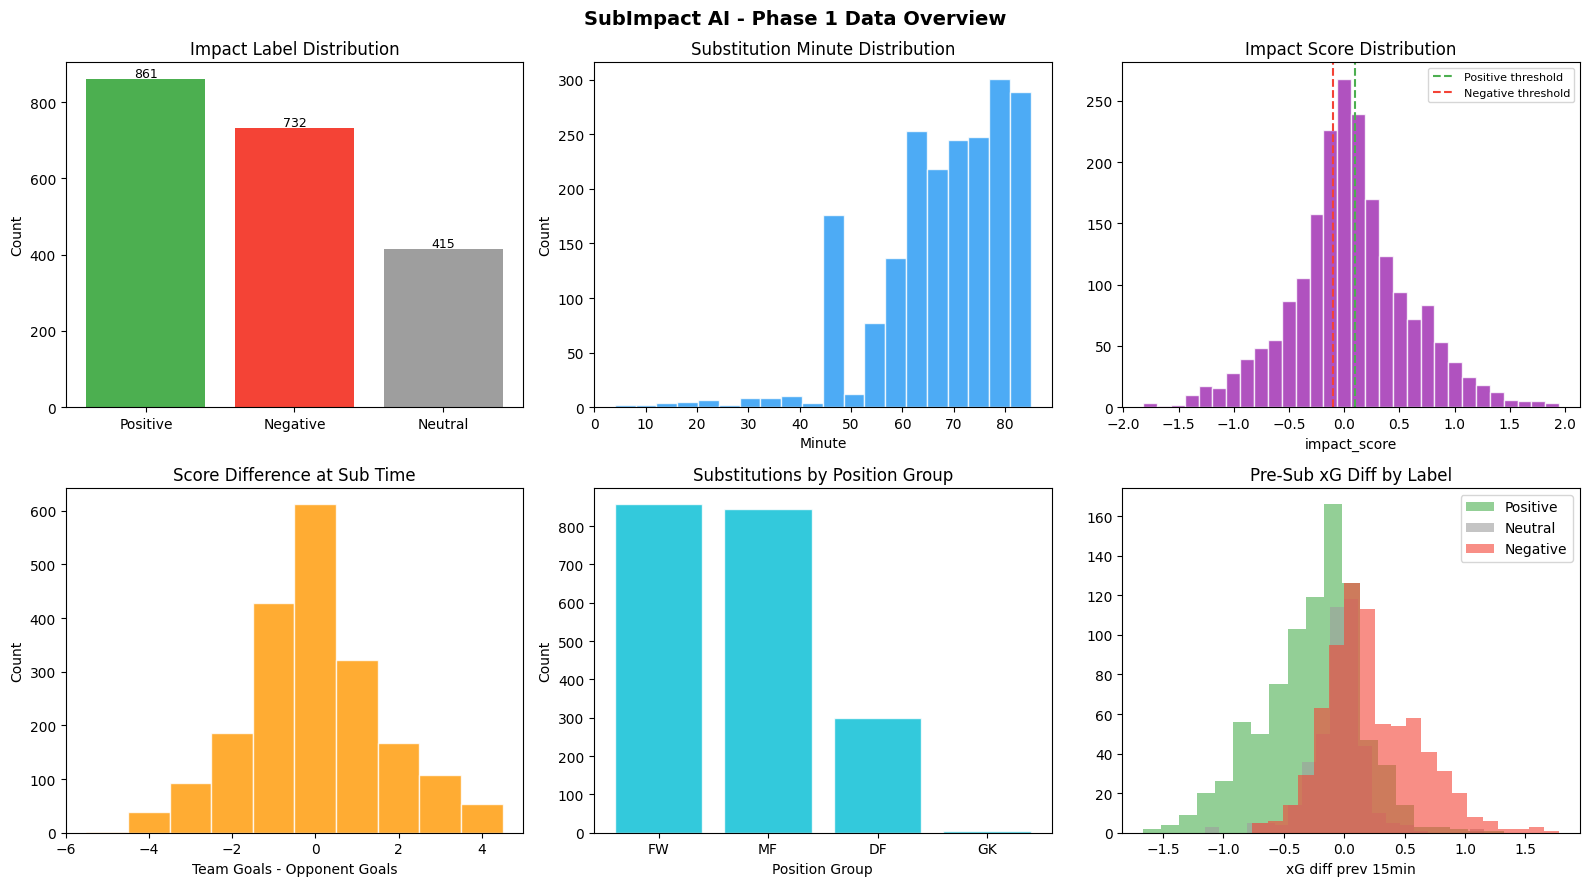

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("SubImpact AI - Phase 1 Data Overview", fontsize=14, fontweight="bold")

# 1. Label distribution
ax = axes[0, 0]
counts = df["impact_label"].value_counts()
colors = {"Positive": "#4CAF50", "Neutral": "#9E9E9E", "Negative": "#F44336"}
bars = ax.bar(counts.index, counts.values, color=[colors.get(l, "#999") for l in counts.index])
ax.set_title("Impact Label Distribution")
ax.set_ylabel("Count")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha="center", fontsize=9)

# 2. Substitution minute distribution
ax = axes[0, 1]
ax.hist(df["sub_minute"], bins=20, color="#2196F3", edgecolor="white", alpha=0.8)
ax.set_title("Substitution Minute Distribution")
ax.set_xlabel("Minute")
ax.set_ylabel("Count")

# 3. Impact score distribution
ax = axes[0, 2]
ax.hist(df["impact_score"], bins=30, color="#9C27B0", edgecolor="white", alpha=0.8)
ax.axvline(IMPACT_POS_THRESHOLD, color="#4CAF50", linestyle="--", label=f"Positive threshold")
ax.axvline(IMPACT_NEG_THRESHOLD, color="#F44336", linestyle="--", label=f"Negative threshold")
ax.set_title("Impact Score Distribution")
ax.set_xlabel("impact_score")
ax.legend(fontsize=8)

# 4. Score diff at sub time
ax = axes[1, 0]
ax.hist(df["score_diff"], bins=range(-5, 6), color="#FF9800", edgecolor="white", alpha=0.8, align="left")
ax.set_title("Score Difference at Sub Time")
ax.set_xlabel("Team Goals - Opponent Goals")
ax.set_ylabel("Count")

# 5. Position group distribution
ax = axes[1, 1]
pos_counts = df["position_group"].value_counts()
ax.bar(pos_counts.index, pos_counts.values, color="#00BCD4", edgecolor="white", alpha=0.8)
ax.set_title("Substitutions by Position Group")
ax.set_xlabel("Position Group")
ax.set_ylabel("Count")

# 6. xG diff before sub by label
ax = axes[1, 2]
for label, color in colors.items():
    subset = df[df["impact_label"] == label]["xg_diff_prev15"]
    ax.hist(subset, bins=20, alpha=0.6, label=label, color=color)
ax.set_title("Pre-Sub xG Diff by Label")
ax.set_xlabel("xG diff prev 15min")
ax.legend()

plt.tight_layout()
plt.show()

In [11]:
print("Training baseline models...")

FEATURE_COLS = [
    "score_diff", "is_home", "time_remaining",
    "sub_sequence", "game_phase_enc",
    "position_group_enc",
    "team_xg_prev15", "opp_xg_prev15", "xg_diff_prev15",
    "shots_prev15", "passes_prev15", "pressures_prev15",
]

TARGET_COL = "impact_label"

model_df = df[FEATURE_COLS + [TARGET_COL]].dropna()
print(f"   Samples used for modeling: {len(model_df)}")

X = model_df[FEATURE_COLS].values
y = model_df[TARGET_COL].values

le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f"   Label classes: {le.classes_}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.20, random_state=42, stratify=y_enc
)
print(f"   Train size: {len(X_train)} | Test size: {len(X_test)}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


def evaluate_model(name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    print(f"\n-- {name} --")
    print(f"   Accuracy  : {acc:.4f}")
    print(f"   Macro F1  : {f1:.4f}")
    print(f"   Macro AUC : {auc:.4f}")
    print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))
    return {"model": name, "accuracy": acc, "macro_f1": f1, "macro_auc": auc}

results = []

Training baseline models...
   Samples used for modeling: 2008
   Label classes: ['Negative' 'Neutral' 'Positive']
   Train size: 1606 | Test size: 402


In [12]:
# Baseline 1: Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)
lr_prob = lr.predict_proba(X_test_sc)
results.append(evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob))


Training Logistic Regression...

-- Logistic Regression --
   Accuracy  : 0.5647
   Macro F1  : 0.5579
   Macro AUC : 0.7590
              precision    recall  f1-score   support

    Negative       0.67      0.61      0.64       147
     Neutral       0.34      0.63      0.44        83
    Positive       0.74      0.50      0.60       172

    accuracy                           0.56       402
   macro avg       0.58      0.58      0.56       402
weighted avg       0.63      0.56      0.58       402



In [13]:
# Baseline 2: Random Forest
print("\nTraining Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)
results.append(evaluate_model("Random Forest", y_test, rf_pred, rf_prob))



Training Random Forest...

-- Random Forest --
   Accuracy  : 0.6443
   Macro F1  : 0.6377
   Macro AUC : 0.8319
              precision    recall  f1-score   support

    Negative       0.76      0.65      0.70       147
     Neutral       0.42      0.75      0.54        83
    Positive       0.79      0.59      0.68       172

    accuracy                           0.64       402
   macro avg       0.66      0.66      0.64       402
weighted avg       0.70      0.64      0.66       402

